# Preparation for Lab 1 - Northe, Velez, Wörner


The source code and the binaries from the spectrum analyzer from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab1_Network_Analysis).

In [17]:
import matplotlib.pyplot as plt
import numpy as np

## Task 1

The connection sketches are presented as follows:
### Filter:

![Prelim_Task1_Filter.png](Prelim_Task1_Filter.png)

### Circulator:
![Prelim_Task1_Circulator.png](Prelim_Task1_Circulator.png)

### Coupler:
![Prelim_Task1_Coupler.png](Prelim_Task1_Coupler.png)

### Line:
![Prelim_Task1_Line.png](Prelim_Task1_Line.png)

### Wilkinson Divider:
![Prelim_Task1_Wilk_Div.png](Prelim_Task1_Wilk_Div.png)

## Task 2

### a) Sketch the measurement setup of the amplifier measurement, which is described in Task 8 of the experimental tasks.

![pic](Prelim_Task3_Circuit.png)

### b) Find maximum power levels according to specifications of a network analyzer (input and output).

As there wasn't a specific model stated, we used this [Rohde & Schwarz ZNA67 datasheet](https://scdn.rohde-schwarz.com/ur/pws/dl_downloads/pdm/cl_brochures_and_datasheets/specifications/5215_4652_22/ZNA_specs_en_5215-4652-22_v2100.pdf)

**Output Test Port from page 24**

![title](ZNA67_max_power_level.png)

**Maximum Input Level from page 27**

At $+27dBm$ is the maximum power level, which can be accepted.

![title](ZNA67_max_damage_level.png)

### c) Determine the maximum allowed output power of a network analyzer for the amplifier of Task 8 without damaging the VNA.

Used [Datasheet of NLB-300](https://www.alldatasheet.com/datasheet-pdf/download/103781/RFMD/NLB-300.html)

The maximum allowed output power of the analyzer is limited to the maximum input values from the LNA. Here the datasheet states that $+20dBm$. <br>
But it has to be considered that the LNA is at its maximum designed specifications. At this input level we exceed parameters like 1dB-Compression point depending on the frequency at $\approx 13dBm$. 

## Task 3

### How do the 16-term, 12-term and 8-term error models differ? Specify the conditions that are assumed to apply to each.

When measuring S-parameters using a VNA, imperfections in the instrument, cables, and switching system introduce systematic errors. To correct for these, mathematical error models are used during calibration. Depending on the level of precision required and the type of measurement setup, different models are applied. <br> 
The errors are:

| Error Term             | Meaning / Description                            | 16-Term | 12-Term | 8-Term |
|------------------------|--------------------------------------------------|:-------:|:-------:|:------:|
| e00 / e33              | Directivity (Fwd / Rev)                          |   ✅    |   ✅    |   ✅   |
| e11 / e22              | Source Match (Fwd / Rev)                         |   ✅    |   ✅    |   ✅   |
| e10·e01 / e23·e32      | Reflection Tracking (Fwd / Rev)                  |   ✅    |   ✅    |   ✅   |
| e22 / e11              | Load Match (Fwd / Rev)                           |   ✅    |   ✅    |        |
| e10·e32 / e23·e01              | Transmission Tracking (Fwd / Rev)               |   ✅    |   ✅    |   ✅   |
|               | Crosstalk / Isolation (Fwd / Rev)               |   ✅    |         |        |

- **Directivity** (Forward/Reverse): Measures how well the VNA can separate incident from reflected waves. E.g. isolate forward-going signals from the reverse signals induced by mismatches<br>
- **Source Match**: Represents mismatch between the VNA’s source port and the DUT. Affects how much of the signal reflects back. <br>
- **Reflection Tracking**: Accounts for frequency response and losses in the signal path when measuring reflections. <br>
- **Load Match**: Represents mismatch at the DUT output or receiving port. Affects transmission accuracy. <br>
- **Transmission Tracking**: Similar to Reflection Tracking, but with also with the error from DUT to VNA <br>

Here we can see the Terms in a 12-Term meassurement [5]: <br>
![title](12TermForward.jpg)
![title](12TermReverse.jpg)

And here the three methods are compared to each other:

| Assumptions             | Meaning / Description                            | 16-Term | 12-Term | 8-Term |
|------------------------|--------------------------------------------------|:-------:|:-------:|:------:|
| Assumes Symmetry       | Hardware is reciprocal                          |         |   ✅    |   ✅   |
| Assumes Isolation      | No Crosstalk                                     |         |         |   ✅   |
| Assumes Identical Ports| Ports behave identically                         |         |         |   ✅   |


## Task 4

### Why is a cable usually standardized to 50 Ohm in microwave technology? What are the advantages?

**50 Ω** is a standardized impedance because it represents a compromise between two competing performance metrics:

- **Maximum power handling** (optimized near **30 Ω**)  
- **Minimum conductor loss** (optimized near **77 Ω**)

---

#### Maximum Power Handling

The peak power is limited by the **electric field strength** at the inner conductor, which must not exceed the dielectric breakdown limit.

Electric field at the inner conductor:

$$
E_{\text{max}} = \frac{V}{a \ln(b/a)}
$$

Solving for the maximum voltage before breakdown $ E_{\text{break}} $:

$$
V_{\text{max}} = E_{\text{break}} \cdot a \ln(b/a)
$$

Power delivered to a matched load:

$$
P = \frac{V_{\text{max}}^2}{2Z_0}
$$

Substitute for \( V_{\text{max}} \):

$$
P \propto \frac{a^2 \ln^2(b/a)}{Z_0}
$$

From the impedance formula:

$$
Z_0 = \frac{60}{\sqrt{\varepsilon_r}} \ln(b/a)
\Rightarrow
P \propto \frac{a^2 \ln(b/a)}{60}
$$

This expression peaks near $ Z_0 \approx 30\ \Omega $, where the cable supports **maximum power** before dielectric breakdown.

---

#### Minimum Attenuation

In the low-loss approximation, the attenuation constant is:

$$
\alpha \approx \frac{R_s}{2Z_0} \left( \frac{1}{a} + \frac{1}{b} \right)
$$

Using:

$$
Z_0 = \frac{60}{\sqrt{\varepsilon_r}} \ln(b/a)
$$

We substitute and minimize $ \alpha $ with respect to the ratio $ \frac{b}{a} $. The optimal value for **minimum attenuation** is:

$$
Z_0 \approx 77\ \Omega
$$

---

The choice of **50 Ω** impedance is a practical engineering compromise:

- Closer to **30 Ω** for good power handling  
- Close enough to **77 Ω** for relatively low conductor loss. Some applications like TV infrastructure, where $75\Omega$ is often used to prioritize this.

This makes 50 Ω a well-balanced standard for **RF/microwave** applications.

Here we visualize the conductor losses and power handling across the Impedance:

In [18]:
b = 1.0  # outer conductor radius (normalized)
epsilon_r = 1.0  # air dielectric constant

In [19]:
a = np.linspace(0.01, 0.9 * b, 500)
ln_ba = np.log(b / a)

Z0 = 60 / np.sqrt(epsilon_r) * ln_ba
Vmax = a * ln_ba
P = Vmax**2 / (2 * Z0)
P_normalized = P / np.max(P)

alpha = (1 / Z0) * (1 / a + 1 / b)
alpha_normalized = alpha / np.min(alpha)

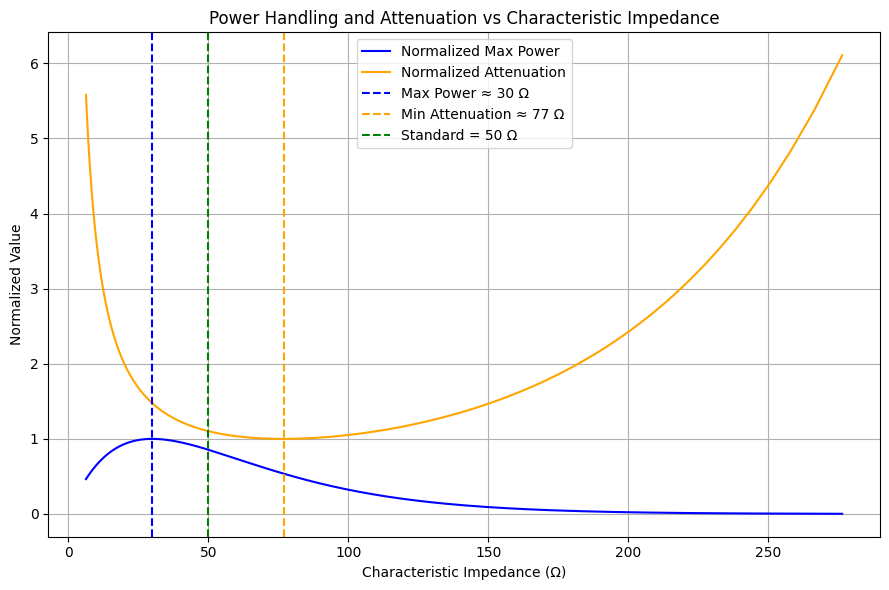

In [20]:
plt.figure(figsize=(9, 6))
plt.plot(Z0, P_normalized, label='Normalized Max Power', color='blue')
plt.plot(Z0, alpha_normalized, label='Normalized Attenuation', color='orange')

plt.axvline(30, color='blue', linestyle='--', label='Max Power ≈ 30 Ω')
plt.axvline(77, color='orange', linestyle='--', label='Min Attenuation ≈ 77 Ω')
plt.axvline(50, color='green', linestyle='--', label='Standard = 50 Ω')

plt.xlabel('Characteristic Impedance (Ω)')
plt.ylabel('Normalized Value')
plt.title('Power Handling and Attenuation vs Characteristic Impedance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

[1] https://www.microwaves101.com/encyclopedias/coax-loss-calculations <br>
[2] https://www.microwaves101.com/encyclopedias/why-fifty-ohms <br>
[3] https://www.allaboutcircuits.com/technical-articles/introduction-to-vna-calibration-techniques/ <br>
[4] https://www.allaboutcircuits.com/technical-articles/understanding-the-12-term-error-model-and-solt-calibration-method-for-vna-measurements/ <br>
[5] http://emlab.uiuc.edu/ece451/appnotes/Rytting_NAModels.pdf <br>
[6] https://coppermountaintech.com/introduction-to-the-metrology-of-vna-measurement/ <br>
[7] Doug Rytting, "Network Analyzer Error Models and Calibration Methods," Agilent Technologies, White Paper, 1998. Available in: http://emlab.uiuc.edu/ece451/appnotes/Rytting_NAModels.pdf <br>
[8] Z. Peterson, "The Mysterious 50 Ohm Impedance: Where It Came From and Why We Use It," Altium Resources, March 4, 2021. [Online]. Available: https://resources.altium.com/p/mysterious-50-ohm-impedance-where-it-came-and-why-we-use-it <br>